<a href="https://colab.research.google.com/github/Thomas-Fabbris/MMIP-polimi/blob/main/Assignments/lecture_14_FISTA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
from matplotlib import pyplot as plt
np.random.seed(42)

Define the problem parameters


In [6]:
A = np.array([[1, 3], [3, 1]])
b = np.array([-1, 2])

lmbda = 0.5

The function to be minimized is $\frac{1}{2}\|Ax-b\|_2^2 + \lambda \|x\|_1$

In [7]:
def f(x): return 0.5 * np.sum((A @ x - b) ** 2)
def F(x): return f(x) + lmbda * np.sum(np.abs(x))


def df(x): return A.T @ (A @ x) - A.T @ b

Plot the function

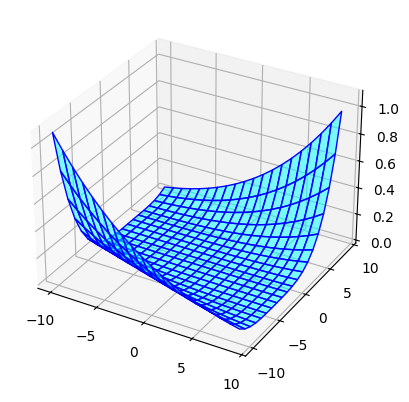

In [8]:
def Fplot(r1, r2): return 0.5 * ((r1 * A[0, 0] + r2 * A[0, 1] - b[0]) ** 2 + (
    r1 * A[1, 0] + r2 * A[1, 1] - b[1])) ** 2 + lmbda * (np.abs(r1) + np.abs(r2))


xx, yy = np.meshgrid(np.arange(-10, 10, 1), np.arange(-10, 10, 1))

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_surface(xx, yy, Fplot(xx, yy), edgecolor=[
                0, 0, 1], alpha=0.5, facecolor=[0, 1, 1])

ISTA with backtracking
----------------------------
Parameters of ISTA

In [9]:
MAX_ITER = 1e3
TOL_DIST_X = 1e-6
# initial value for alpha
alpha = 1
# parameter for backtracking
eta = 0.99

Initialization: test different inizializations, the function is convex, you always converge to the same solution

In [20]:
x = np.array([-5, 10])

grad_norm = 1e10
distanceX = 1e10

# initialize the list with all the estimates
all_x = [x]
x_past = x

Main loop

In [ ]:
cnt = 0
alpha_current = alpha
while (cnt < MAX_ITER and distanceX > TOL_DIST_X):

    # compute the argument of the proximal operator
    x_current = x_past - alpha_current * df(x_past)

    # perform soft thresholding of x
    x_current = np.sign(x_current) * \
        np.maximum(np.abs(x_current) - alpha_current * lmbda, 0)

    # iterate the backtracking proced
    # ure until the stopping criterion is met
    while f(x_current) > f(x_past) + np.dot(df(x_past), x_current - x_past):
        cnt = cnt + 1
        # update alpha
        alpha_current = eta * alpha_current

        x_current = x_past - alpha_current * df(x_past)

        # perform soft thresholding of x
        x_current = np.sign(x_current) * \
            np.maximum(np.abs(x_current) - alpha_current * lmbda, 0)

    # compute the stopping criteria
    distanceX = np.linalg.norm(x_current - x_past)

    x = x_current.copy()

    # store the estimate
    all_x.append(x_current)

Plot all the estimates

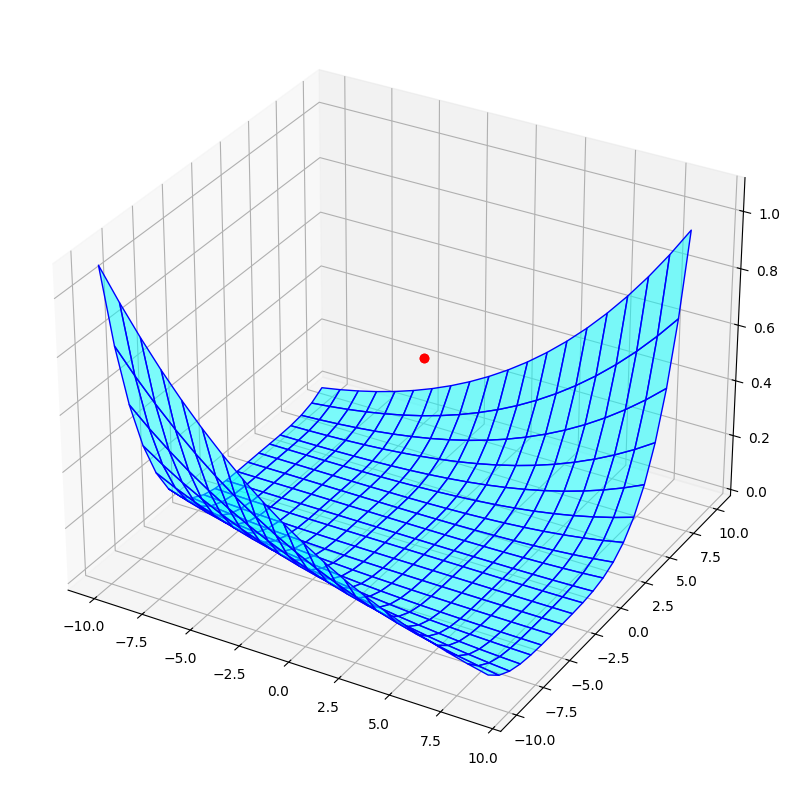

In [24]:
# plot the new estimate
xxplot = [x[0] for x in all_x]
yyplot = [x[1] for x in all_x]
zzplot = Fplot(np.array(xxplot), np.array(yyplot))

fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection='3d')
ax.plot_surface(xx, yy, Fplot(xx, yy), edgecolor=[
                0, 0, 1], alpha=0.5, facecolor=[0, 1, 1])
ax.plot3D(xxplot, yyplot, zzplot, 'r-o')

Compare the number of iteration needed for convergence with backtracking with the number of iteration required using the optimal alpha

In [25]:
print(
    f'nr of iteration of ISTA with backtracking (before stopping criteria met): {cnt}\n')
print(f'Solution of ISTA: [{x_current[0]:.4f}, {x_current[1]:.4f}]\n')
print(f'Value of the functional: {F(x_current):.4f}\n')

nr of iteration of ISTA with backtracking (before stopping criteria met): 2000

Solution of ISTA: [-5.0000, 10.0000]

Value of the functional: 370.0000



FISTA
-----
Parameters of FISTA

In [ ]:
MAX_ITER = 1e3
TOL_DIST_X = 1e-6
# set the optimal value for alpha
# alpha =

Initialization: test different inizializations, the function is convex, you always converge to the same solution

In [ ]:
# initialize x
# x =

# initialize y
# y =

# initialize gamma
# gamma =

grad_norm = 1e10
distanceX = 1e10

# initialize the list with all the estimates
all_x = [x]

Main loop

In [ ]:
cnt = 0
while :
    # compute the argument of the proximal operator

    # perform soft thresholding of x

    # update gamma

    # update y

    # compute the stopping criteria

    # store the estimate


Plot all the estimates

In [ ]:
# plot the new estimate
xxplot = [x[0] for x in all_x]
yyplot = [x[1] for x in all_x]
zzplot = Fplot(np.array(xxplot), np.array(yyplot))

fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection='3d')
ax.plot_surface(xx, yy, Fplot(xx, yy), edgecolor=[
                0, 0, 1], alpha=0.5, facecolor=[0, 1, 1])
ax.plot3D(xxplot, yyplot, zzplot, 'r-o')

In [ ]:
print(f'nr of iteration of FISTA (before stopping criteria met): {cnt}\n')
print(f'Solution of FISTA: [{x_current[0]:.4f}, {x_current[1]:.4f}]\n')
print(f'Value of the functional: {F(x_current):.4f}\n')